# Predizione del

Questo notebook è una struttura generale da usare come base per il progetto.

Compilate ogni sezione con:
- testo descrittivo
- codice
- grafici
- commenti ai risultati

---

## Titolo del progetto
**Inserire qui il titolo**

## Studente 
Aurora Loprino


# 1. Introduzione del problema
## Predizione del Rischio di Diabete

Il diabete mellito di tipo 2 è una delle malattie croniche più diffuse al mondo. 
Secondo l'OMS, circa 422 milioni di persone ne sono affette e il numero è in continua crescita.
(WHO, Global Report on Diabetes, 2016 — https://www.who.int/publications/i/item/9789241565257)

Una diagnosi precoce è fondamentale per rallentare la progressione della malattia e ridurre le complicanze da lei causata, quali neuropatia, retinopatia e malattie cardiovascolari.

Questo progetto si pone di costruire un modello di classificazione capace di prevedere se un paziente è a rischio di diabete sulla base di misure cliniche facilmente rilevabili.
Un sistema di questo tipo potrebbe supportare i medici di base nello screening preventivo, consentendo di identificare pazienti a rischio prima che sviluppino sintomi conclamati.

Tipo di task > classificazione binaria
- Classe 0: paziente non diabetico
- Classe 1: paziente diabetico


In questa sezione descrivere:
- il problema che si vuole affrontare // ok
- il tipo di task (classificazione, clustering, forecasting, regressione, outlier detection, ecc.) // revisionare dopo
- l'obiettivo del progetto // ok
- l'interesse pratico o applicativo del problema // ok


# 2. Descrizione del dataset

Il dataset utilizzato è il **Pima Indians Diabetes Dataset**, originariamente raccolto dal *National Institute of Diabetes and Digestive and Kidney Diseases*. E' disponibile su varie piattaforme, io l'ho recuperato da (Github - https://gist.github.com/ktisha/c21e73a1bd1700294ef790c56c8aec1f)

Tra le variabili abbiamo:
* **Pregnancies** - Numero di gravidanze 
* **Glucose** - Concentrazione di glucosio nel plasma (mg/dL) dopo test di tolleranza 
* **BloodPressure** - Pressione diastolica (mm Hg) 
* **SkinThickness** - Spessore della piega cutanea del tricipite (mm) 
* **Insulin** - Livello di insulina a 2 ore (mu U/ml) 
* **BMI** - Indice di massa corporea (kg/m²) 
* **DiabetesPedigreeFunction** - Funzione che stima la predisposizione genetica al diabete 
* **Age** - Età in anni
* **Outcome** - Se 0 = non diabetico, altrimenti 1 = diabetico 

E' un dataset di 768 righe × 9 colonne e tutte le pazienti sono donne di almeno 21 anni di etnia Pima (nativi americani dell'Arizona), una popolazione storicamente ad alto rischio di diabete di tipo 2.




In questa sezione inserire:
- origine del dataset // ok
- descrizione delle variabili // ok
- eventuale variabile target // ok
- dimensione del dataset // ok
- eventuali note sul contesto dei dati // ok


# 3. Lettura e preparazione dei dati

In questa sezione inserire:
- caricamento del dataset // ok
- controllo dei tipi di dato // ok
- verifica di valori mancanti // ok
- eventuali trasformazioni iniziali // ok
- eventuale encoding / scaling / gestione date o categorie // ok


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [28]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, classification_report)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

print('Librerie caricate correttamente.')

Librerie caricate correttamente.


In [29]:
df = pd.read_csv(
    'Dataset/pima-indians-diabetes.csv',
    comment='#',
    header=None,
    names=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']
)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Ora controllo i tipi di dato, verificando che tutte le colonne siano numeriche.

In [30]:
print('Tipi di dato:')
print(df.dtypes)

Tipi di dato:
Pregnancies           int64
Glucose               int64
BloodPressure         int64
SkinThickness         int64
Insulin               int64
BMI                 float64
DiabetesPedigree    float64
Age                   int64
Outcome               int64
dtype: object


Il dataset mostra dei valori 0, cioè dati mancanti. Andiamo a contare quanti zeri ci sono per ogni colonna  biologicamente impossibile.

In [31]:
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Conteggio zeri per variabile:')
for col in zero_features:
    n = (df[col] == 0).sum()
    print(f'{col}: {n} ({n/len(df)*100:.1f}%)')


Conteggio zeri per variabile:
Glucose: 5 (0.7%)
BloodPressure: 35 (4.6%)
SkinThickness: 227 (29.6%)
Insulin: 374 (48.7%)
BMI: 11 (1.4%)


Converto gli zero a NaN

In [32]:
df_clean = df.copy()
df_clean[zero_features] = df_clean[zero_features].replace(0, np.nan)

print('Valori mancanti dopo sostituzione:')
print(df_clean.isnull().sum())

Valori mancanti dopo sostituzione:
Pregnancies           0
Glucose               5
BloodPressure        35
SkinThickness       227
Insulin             374
BMI                  11
DiabetesPedigree      0
Age                   0
Outcome               0
dtype: int64


Imputo i valori mancanti con la mediana calcolata separatamente per classe (Outcome=0 e Outcome=1), dato i valori fisiologici differiscono tra soggetti diabetici e non diabetici

In [33]:
for col in zero_features:
    df_clean[col] = df_clean.groupby('Outcome')[col].transform(
        lambda x: x.fillna(x.median())
    )

print(df_clean.isnull().sum())

Pregnancies         0
Glucose             0
BloodPressure       0
SkinThickness       0
Insulin             0
BMI                 0
DiabetesPedigree    0
Age                 0
Outcome             0
dtype: int64


# 4. Visualizzazione ed EDA

Ora esploriamo le caratteristiche del dataset attraverso statistiche descrittive e visualizzazioni, con l'obiettivo di comprendere le distribuzioni, le relazioni tra feature e target, e i potenziali problemi, quali sbilanciamento delle classi, outlier e correlazioni.

- statistiche descrittive // ok
- visualizzazioni utili a comprendere il dataset // ok
- distribuzioni delle variabili // ok
- relazioni tra feature // ok
- eventuali correlazioni // ok
- osservazioni emerse dall'analisi esplorativa // direi che ci sono?? revisionare dopo


In [34]:
df_clean.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.68,72.39,29.09,141.75,32.43,0.47,33.24,0.35
std,3.37,30.46,12.11,8.89,89.10,6.88,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.75,64.00,25.00,102.50,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,28.00,102.50,32.05,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,169.50,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


Mostra media, deviazione standard, min, max e quartili per ogni colonna.

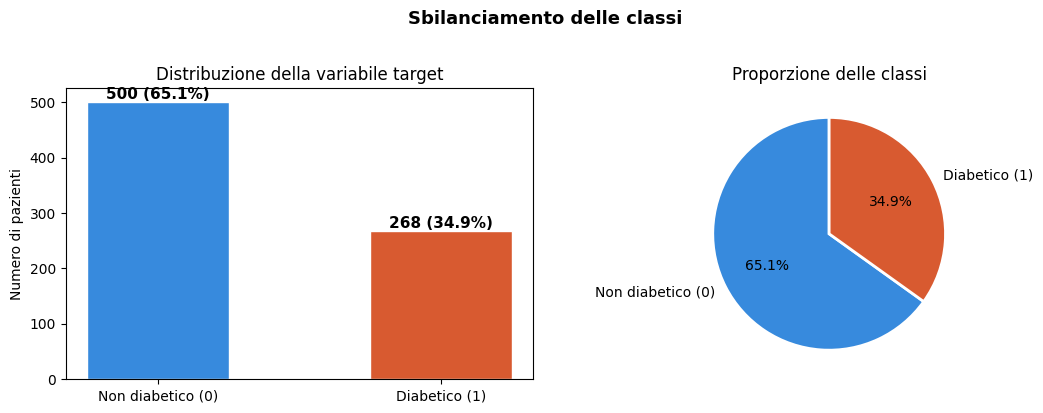

Non diabetici: 500 (65.1%)
Diabetici:     268 (34.9%)


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df_clean['Outcome'].value_counts().sort_index()
labels = ['Non diabetico (0)', 'Diabetico (1)']
colors = ['#378ADD', '#D85A30']

axes[0].bar(labels, counts.values, color=colors, width=0.5, edgecolor='white')
axes[0].set_title('Distribuzione della variabile target')
axes[0].set_ylabel('Numero di pazienti')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, f'{v} ({v/len(df_clean)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporzione delle classi')

plt.suptitle('Sbilanciamento delle classi', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

pct0 = counts[0] / len(df_clean) * 100
pct1 = counts[1] / len(df_clean) * 100
print(f'Non diabetici: {counts[0]} ({pct0:.1f}%)')
print(f'Diabetici:     {counts[1]} ({pct1:.1f}%)')

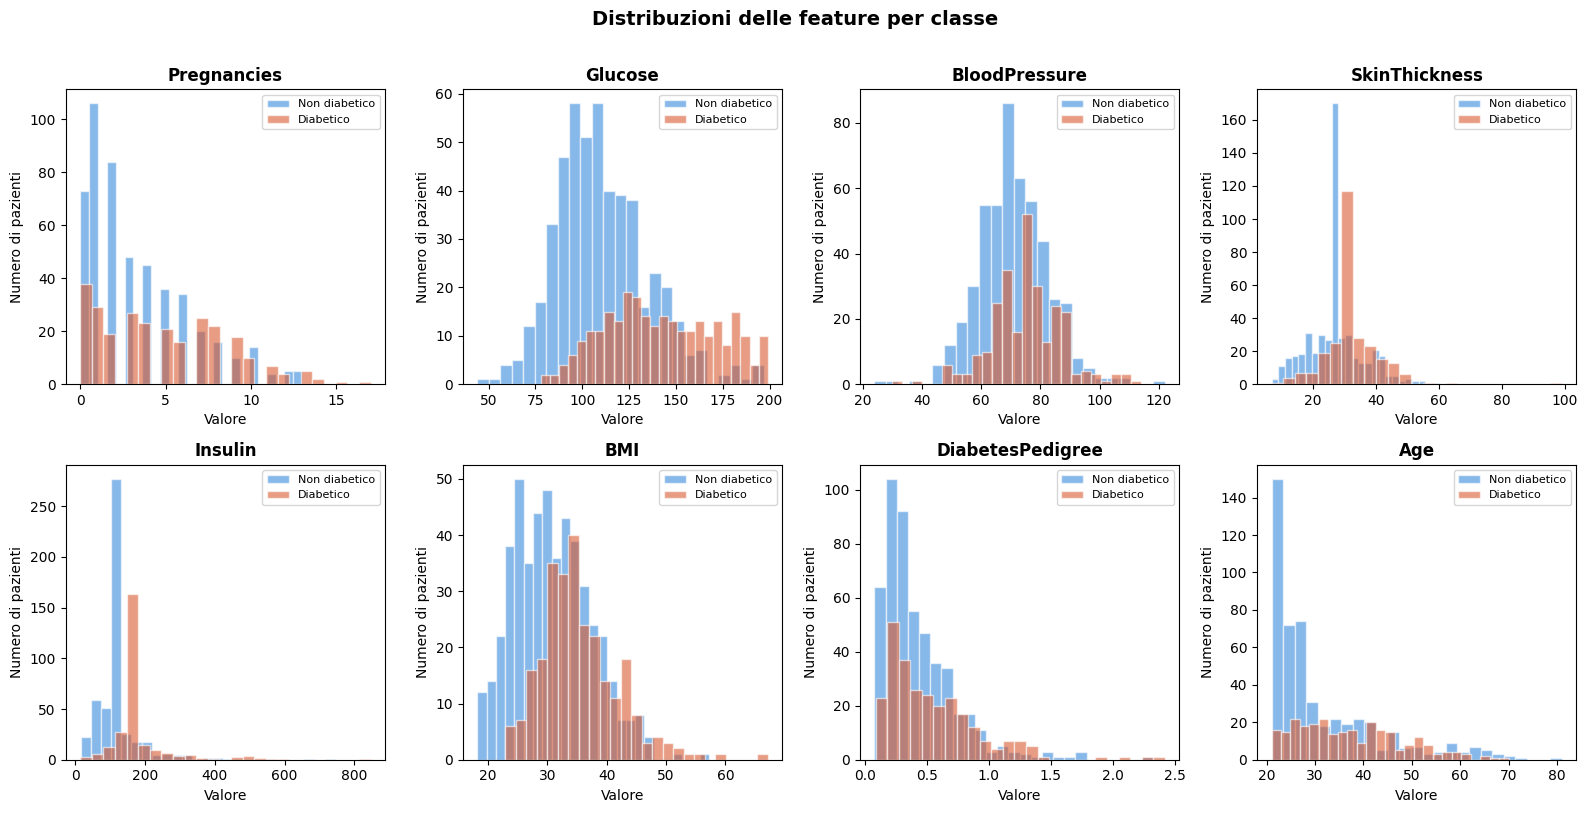

In [45]:
feature_cols = [c for c in df_clean.columns if c != 'Outcome']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    for outcome, color, label in [(0, '#378ADD', 'Non diabetico'), (1, '#D85A30', 'Diabetico')]:
        subset = df_clean[df_clean['Outcome'] == outcome][col]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Valore')
    axes[i].set_ylabel('Numero di pazienti')
    axes[i].legend(fontsize=8)


plt.suptitle('Distribuzioni delle feature per classe', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Ogni istogramma mostra dove si concentrano i valori di una feature, separati per persone con diabete (in rosso) e persone sane (in blu).

* Glucose è una feature discriminante. Le persone con diabete hanno valori di glucosio concentrati più a destra (valori alti), mentre chi è sano si trova più a sinistra. 
Le due distribuzioni sono ben separate, quindi il modello può usare il glucosio per distinguere i due gruppi con buona affidabilità.

* BMI è moderatamente discriminante. Le persone con diabete tendono ad avere un BMI più alto, ma le distribuzioni si sovrappongono di più rispetto al glucosio. La separazione c'è ma è meno netta.

* Age è moderatamente discriminante. Le persone con diabete sono mediamente più anziane. Anche qui c'è sovrapposizione, ma la tendenza è visibile.

* Insulin e SkinThickness sono poco discriminanti. Le distribuzioni dei due gruppi si sovrappongono quasi completamente, quindi guardando solo questi valori è difficile capire se un paziente è diabetico o no. Contribuiscono poco da soli, ma possono aiutare in combinazione con le altre feature.

* Pregnancies è poco discriminante. Le donne diabetiche tendono ad avere più gravidanze, ma la sovrapposizione è alta.

* DiabetesPedigree e Blood pressure sono le features meno discriminanti. Le distribuzioni dei due gruppi sono molto simili; da sole non aiuterebbero a fare una buona distinzione.




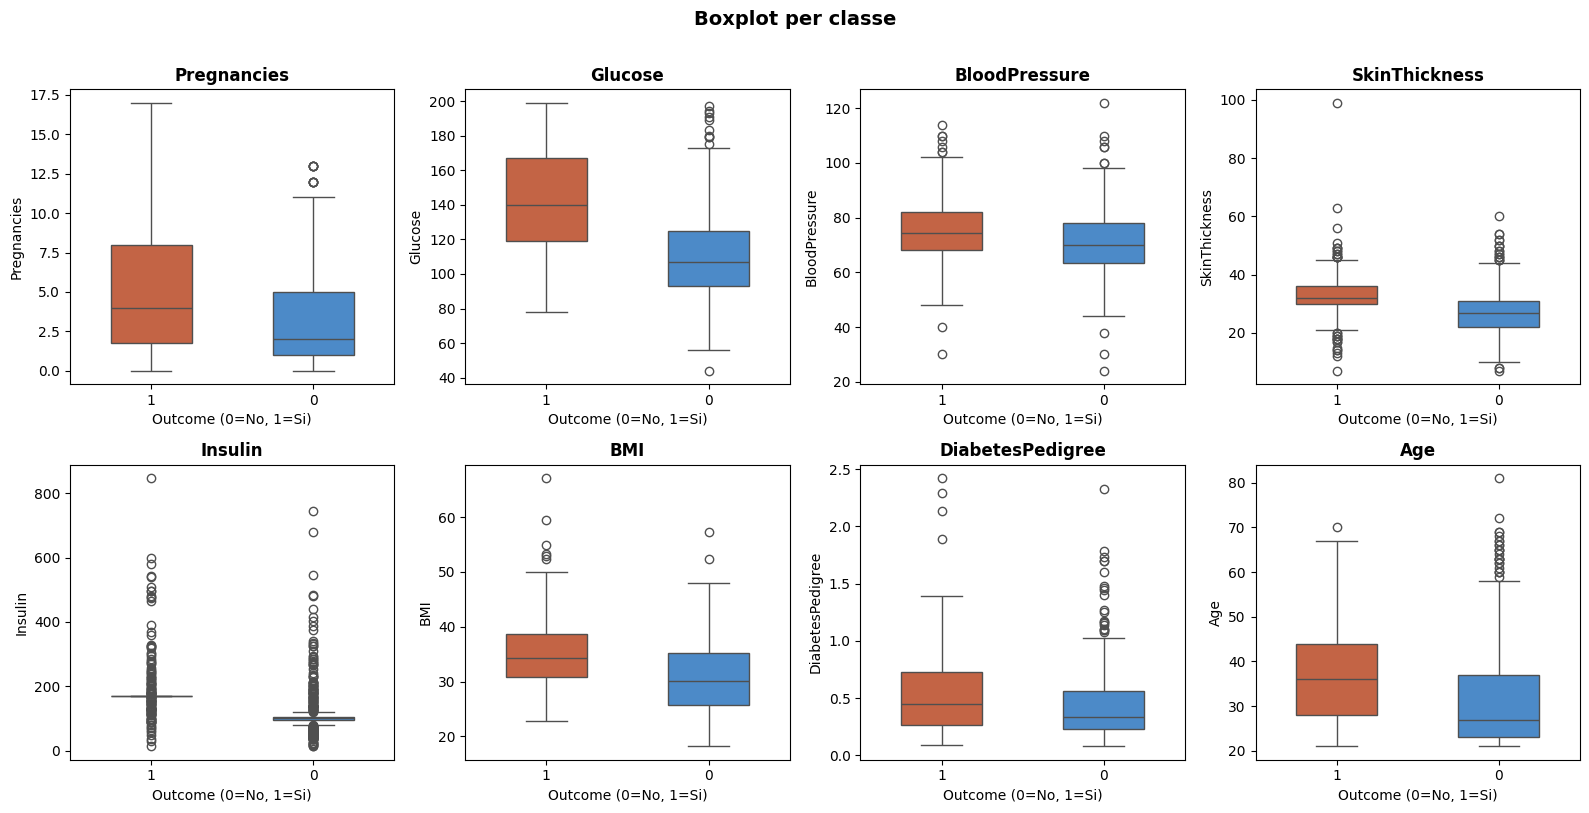

In [42]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

palette = {'0': '#378ADD', '1': '#D85A30'}
df_clean['Outcome'] = df_clean['Outcome'].astype(str)

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df_clean, x='Outcome', y=col, hue='Outcome',
                palette=palette, legend=False, ax=axes[i], width=0.5)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Outcome (0=No, 1=Si)')

plt.suptitle('Boxplot per classe', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

df_clean['Outcome'] = df_clean['Outcome'].astype(int)


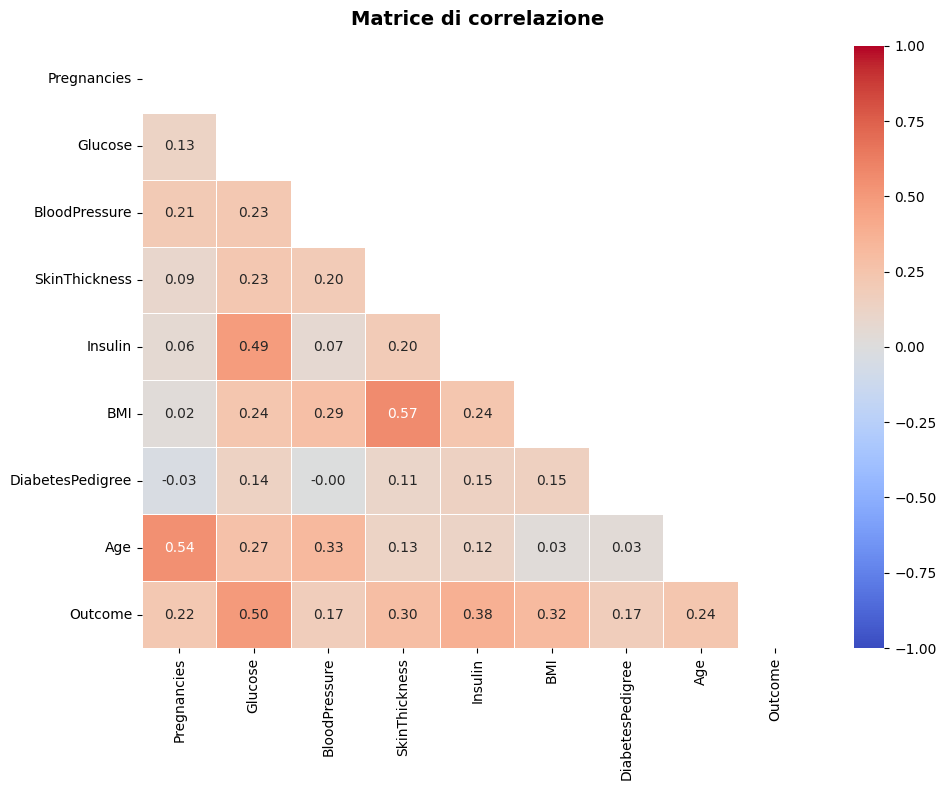

Correlazioni con Outcome (ordinate):
Glucose             0.496
Insulin             0.377
BMI                 0.316
SkinThickness       0.295
Age                 0.238
Pregnancies         0.222
BloodPressure       0.174
DiabetesPedigree    0.174
Name: Outcome, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) # NTS, rimuove la metà alta per non ripetere i dati!!!!
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 10}, linewidths=0.5)
ax.set_title('Matrice di correlazione', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('Correlazioni con Outcome (ordinate):')
print(corr['Outcome'].drop('Outcome').sort_values(ascending=False).round(3))


Mostra quanto ogni coppia di variabili è correlata.
Le correlazioni con Outcome ordinate mostrano quali feature sono più predittive.

* Glucose (0.496) è definitivamente la più predittiva; il livello di glucosio è anche il segnale più forte per il diabete, quindi ha anche senso clinicamente.

* Insulin (0.377), BMI (0.316) e SkinThickness (0.295) hanno una correlazione moderata, contribuiscono ma da soli non basterebbero.

* Age (0.238), Pregnancies (0.222) hanno una correlazione presente...ma anche debole.

* BloodPressure (0.174), DiabetesPedigree (0.174) sono le meno correlate, ma non per forza inutili al modello.

Nessun valore è vicino a 1, il che significa che nessuna singola feature è sufficiente e il modello dovrà combinarle tutte, come aspettato.

# 5. Outlier detection / preprocessing

In questa sezione affrontare:
- valori anomali
- valori improbabili o critici
- eventuali strategie di pulizia
- tecniche di outlier detection
- motivazione delle scelte di preprocessing finale


In [46]:
for col in feature_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)).sum()
    print(f'{col}: {n_out} ({n_out/len(df_clean)*100:.1f}%)')


Pregnancies: 4 (0.5%)
Glucose: 0 (0.0%)
BloodPressure: 14 (1.8%)
SkinThickness: 87 (11.3%)
Insulin: 51 (6.6%)
BMI: 8 (1.0%)
DiabetesPedigree: 29 (3.8%)
Age: 9 (1.2%)


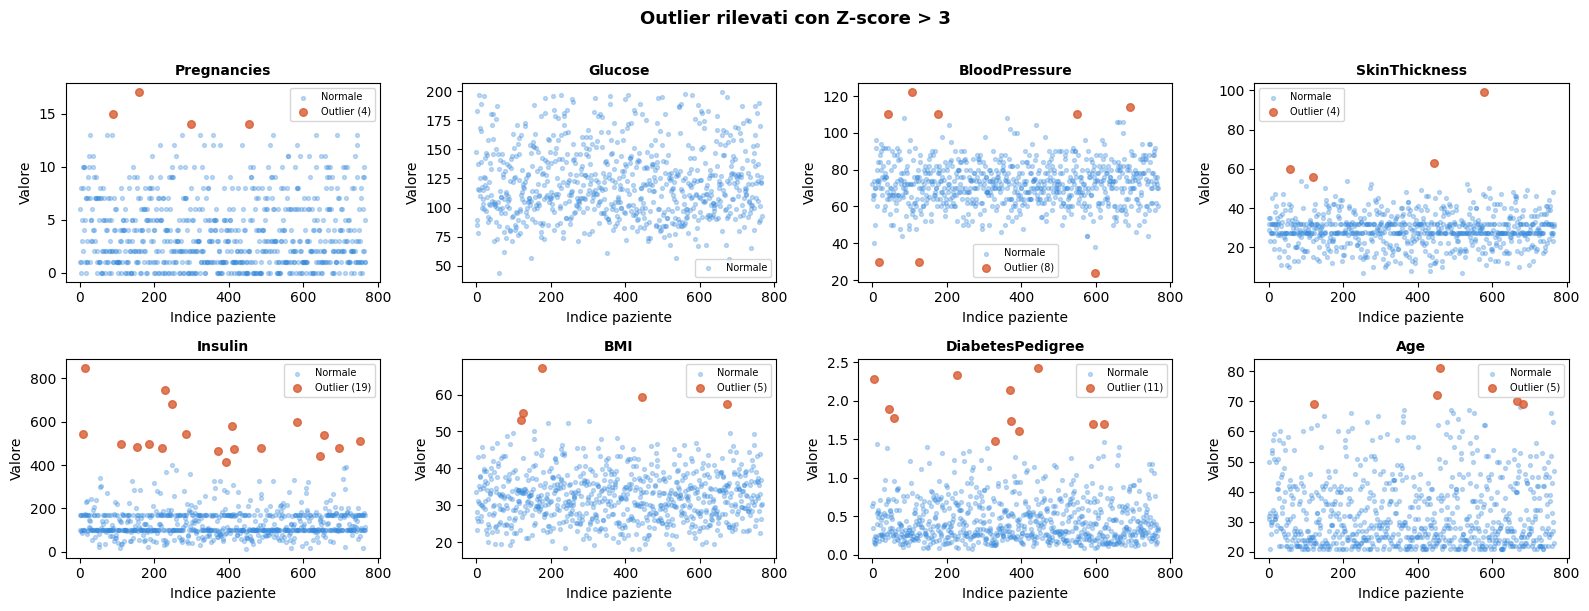

In [47]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    z = np.abs(stats.zscore(df_clean[col]))
    normal = df_clean[col][z <= 3]
    outliers = df_clean[col][z > 3]
    axes[i].scatter(normal.index, normal.values, alpha=0.3, s=8, color='#378ADD', label='Normale')
    if len(outliers) > 0:
        axes[i].scatter(outliers.index, outliers.values, alpha=0.8, s=30,
                        color='#D85A30', label=f'Outlier ({len(outliers)})', zorder=5)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Indice paziente')
    axes[i].set_ylabel('Valore')
    axes[i].legend(fontsize=7)

plt.suptitle('Outlier rilevati con Z-score > 3', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


# 6. Implementazione di uno o più modelli

In questa sezione descrivere:
- i modelli scelti
- le motivazioni della scelta
- lo split train/test oppure altra strategia di validazione
- l'addestramento dei modelli
- eventuali confronti tra metodi diversi


# 7. Valutazione e confronto dei risultati

In questa sezione inserire:
- metriche di valutazione
- grafici di confronto
- eventuale confusion matrix o altri strumenti diagnostici
- confronto tra modelli o approcci
- interpretazione critica dei risultati


# 8. Conclusioni finali

In questa sezione riassumere:
- il problema affrontato
- il metodo seguito
- i risultati principali
- le conclusioni più importanti
- eventuali limiti del lavoro svolto
